# Amazon Fine Food Reviews Data Analysis

## Context of Dataset

This dataset consists of reviews of fine foods from amazon. The data span a period of more than 10 years. Reviews include product and user information, ratings, and a plain text review. It also includes reviews from all other Amazon categories.

## Project Goal

The goal of this project is to explore the Amazon Fine Food Reviews dataset using Pandas and Polars. The analysis includes inspecting the dataset, checking data quality, filtering and grouping reviews, creating a visualization, and beginning an exploration of a machine learning model.

## The machine learning task will use review text to predict whether a review is positive or negative.

## 1.Load Packages

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

## 2. Import the Dataset and Inspect the Data

The dataset is loaded from the local `data` directory using Pandas, since the CSV itself is too large to upload to Github (300 Mb). The loading time is recorded so it can later be compared with Polars.

In [14]:
DATA_PATH = Path("data") / "Reviews.csv"

reviews = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {reviews.shape}")

Dataset shape: (568454, 10)


In [15]:
reviews.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


**Finding**: Here we can see that the original `Time` column contains Unix timestamps, and we want these values to be converted into readable dates. We will do the date conversion.

In [16]:
reviews["ReviewDate"] = pd.to_datetime(reviews["Time"], unit="s")

reviews[["Time", "ReviewDate"]].head()

,Time,ReviewDate
0,1303862400,2011-04-27
1,1346976000,2012-09-07
2,1219017600,2008-08-18
3,1307923200,2011-06-13
4,1350777600,2012-10-21


In [17]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype        
---  ------                  --------------   -----        
 0   Id                      568454 non-null  int64        
 1   ProductId               568454 non-null  str          
 2   UserId                  568454 non-null  str          
 3   ProfileName             568428 non-null  str          
 4   HelpfulnessNumerator    568454 non-null  int64        
 5   HelpfulnessDenominator  568454 non-null  int64        
 6   Score                   568454 non-null  int64        
 7   Time                    568454 non-null  int64        
 8   Summary                 568427 non-null  str          
 9   Text                    568454 non-null  str          
 10  ReviewDate              568454 non-null  datetime64[s]
dtypes: datetime64[s](1), int64(5), str(5)
memory usage: 47.7 MB


In [18]:
print(f"Earliest review date: {reviews['ReviewDate'].min()}")
print(f"Latest review date: {reviews['ReviewDate'].max()}")

Earliest review date: 1999-10-08 00:00:00
Latest review date: 2012-10-26 00:00:00


**Finding:** After converting the Unix timestamps, the dataset was found to cover reviews from 1999-10-08 through 2012-10-26.

### Summary Statistics

Descriptive statistics are calculated for the numerical columns to examine their distributions, ranges, and average values.

In [19]:
reviews.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,ReviewDate
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05,568454
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09,2011-01-28 23:16:44
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08,1999-10-08 00:00:00
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09,2010-04-15 00:00:00
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09,2011-07-20 00:00:00
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09,2012-03-26 00:00:00
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09,2012-10-26 00:00:00
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07,NaN


### Check for Missing Values or Duplicated Rows


In [20]:
missing_values = reviews.isna().sum()

missing_values

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
ReviewDate                 0
dtype: int64

**Finding:** The dataset contains 26 missing values in `ProfileName` and 27 missing values in `Summary`. All other columns have no missing values. Because the missing values represent a very small proportion of the dataset and do not affect the variables used for the planned machine learning analysis, no rows are removed.

In [21]:
duplicate_count = reviews.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [22]:
print(f"Number of unique IDs: {reviews['Id'].nunique()}")
print(f"Total number of rows: {len(reviews)}")

Number of unique IDs: 568454
Total number of rows: 568454


**Finding**: There are no duplicated rows, so we will continue with the filtering and grouping in Pandas.

## 3. Filtering and Grouping

Since we are analyzing food reviews, we want to see which reviews are helpful and whether these reviews align with the star ratings. We will use Pandas and Polars to analyze, and focus on the following questions in this part:

1. Which positive reviews received substantial feedback and were considered helpful by most readers?
2. How do review counts and average helpful votes differ across star ratings?

We will first create a new variable called **"Helpfulness Ratio"**. In the dataset, we can see that there are two variables called `"HelpfulnessNumerator"` and `"HelpfulnessDenominator"`, so we will let `Helpfulness Ratio` represents the proportion of voters who considered a review helpful. The ratio is calculated only for reviews that received at least one helpfulness vote to avoid division by zero.

In [23]:
reviews["HelpfulnessRatio"] = pd.NA

has_votes = reviews["HelpfulnessDenominator"] > 0

reviews.loc[has_votes, "HelpfulnessRatio"] = (reviews.loc[has_votes, "HelpfulnessNumerator"] /reviews.loc[has_votes, "HelpfulnessDenominator"])

reviews[
    [
        "HelpfulnessNumerator",
        "HelpfulnessDenominator",
        "HelpfulnessRatio",
    ]
].head(10)

,HelpfulnessNumerator,HelpfulnessDenominator,HelpfulnessRatio
0,1,1,1.0
1,0,0,<NA>
2,1,1,1.0
3,3,3,1.0
4,0,0,<NA>
5,0,0,<NA>
6,0,0,<NA>
7,0,0,<NA>
8,1,1,1.0
9,0,0,<NA>


### Filtering Highly Helpful Positive Reviews

A review is defined as a highly helpful positive review if it:

- has a score of 4 or 5;
- has received at least 10 helpfulness votes; and
- has a helpfulness ratio of at least 80%.

Requiring at least 10 votes prevents a review with only one positive vote from being treated as strongly supported, since 1 helpful vote out of 1 = 100%, not enough evidence that the review is strongly supported.

In [24]:
helpful_positive_reviews = reviews[
    (reviews["Score"] >= 4)
    & (reviews["HelpfulnessDenominator"] >= 10)
    & (reviews["HelpfulnessRatio"] >= 0.80)
].copy()

print(
    "Number of highly helpful positive reviews:",
    len(helpful_positive_reviews),
)

Number of highly helpful positive reviews: 12550


In [25]:
helpful_positive_reviews[
    [
        "ProductId",
        "Score",
        "HelpfulnessNumerator",
        "HelpfulnessDenominator",
        "HelpfulnessRatio",
        "Summary",
    ]
].sort_values(
    by="HelpfulnessDenominator",
    ascending=False,
).head(10)

,ProductId,Score,HelpfulnessNumerator,HelpfulnessDenominator,HelpfulnessRatio,Summary
190733,B000FI4O90,5,866,878,0.986333,Works as Advertised - Classy Product
566779,B001PQTYN2,5,808,815,0.991411,sauce not for mortals
385450,B0051SU0OW,5,559,562,0.994662,Works great! But how does it compare to Solofi...
373575,B009K2BBQG,5,559,562,0.994662,Works great! But how does it compare to Solofi...
297366,B0069GOKGE,5,559,562,0.994662,Works great! But how does it compare to Solofi...
287184,B009K2BBT8,5,559,562,0.994662,Works great! But how does it compare to Solofi...
467800,B0065G59F4,5,559,562,0.994662,Works great! But how does it compare to Solofi...
293135,B008VQ01Y0,5,559,562,0.994662,Works great! But how does it compare to Solofi...
116802,B008F2K1YU,5,559,562,0.994662,Works great! But how does it compare to Solofi...
210511,B005FKRTO0,5,559,562,0.994662,Works great! But how does it compare to Solofi...


**Finding:** A total of 12550 reviews met the criteria for highly helpful positive reviews.

### Grouping Reviews with Polars

Polars is used to group reviews by star rating and calculate the number of reviews, average helpful votes, and average total votes for each rating.

In [30]:
reviews_polar = pl.read_csv(DATA_PATH)

reviews_polar.head(5)

Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
i64,str,str,str,i64,i64,i64,i64,str,str
1,"""B001E4KFG0""","""A3SGXH7AUHU8GW""","""delmartian""",1,1,5,1303862400,"""Good Quality Dog Food""","""I have bought several of the V…"
2,"""B00813GRG4""","""A1D87F6ZCVE5NK""","""dll pa""",0,0,1,1346976000,"""Not as Advertised""","""Product arrived labeled as Jum…"
3,"""B000LQOCH0""","""ABXLMWJIXXAIN""","""Natalia Corres ""Natalia Corres…",1,1,4,1219017600,"""""Delight"" says it all""","""This is a confection that has …"
4,"""B000UA0QIQ""","""A395BORC6FGVXV""","""Karl""",3,3,2,1307923200,"""Cough Medicine""","""If you are looking for the sec…"
5,"""B006K2ZZ7K""","""A1UQRSCLF8GW1T""","""Michael D. Bigham ""M. Wassir""""",0,0,5,1350777600,"""Great taffy""","""Great taffy at a great price. …"


In [31]:
score_summary_polar = (
    reviews_polar
    .group_by("Score")
    .agg(
        pl.len().alias("ReviewCount"),
        pl.col("HelpfulnessNumerator")
        .mean()
        .alias("AverageHelpfulVotes"),
        pl.col("HelpfulnessDenominator")
        .mean()
        .alias("AverageTotalVotes"),
    )
    .sort("Score")
)

score_summary_polar

Score,ReviewCount,AverageHelpfulVotes,AverageTotalVotes
i64,u32,f64,f64
1,52268,2.735211,4.869825
2,29769,1.859014,3.102724
3,42640,1.700962,2.466393
4,80655,1.390292,1.666084
5,363122,1.675228,1.874108


In [32]:
score_summary_polar = score_summary_polar.with_columns(
    (
        pl.col("ReviewCount")
        / pl.col("ReviewCount").sum()
        * 100
    ).alias("Percentage")
)

score_summary_polar

Score,ReviewCount,AverageHelpfulVotes,AverageTotalVotes,Percentage
i64,u32,f64,f64,f64
1,52268,2.735211,4.869825,9.194763
2,29769,1.859014,3.102724,5.236835
3,42640,1.700962,2.466393,7.501047
4,80655,1.390292,1.666084,14.188483
5,363122,1.675228,1.874108,63.878871


**Findings:**

- Five-star reviews are the most common, accounting for approximately 63.88% of all reviews.
- Four-star reviews account for approximately 14.19% of the dataset.
- Together, four and five-star reviews make up the majority of the dataset, indicating that the review scores are strongly concentrated toward positive ratings.
- One-star reviews received the highest average number of helpful votes and the highest average number of total votes. This suggests that strongly negative reviews generated more reader voting activity on average. However, average vote counts alone do not necessarily mean that these reviews had a higher helpfulness ratio.

## 4. Visualization

A bar chart is used to display the percentage of reviews associated with each star rating. Bar chart is appropriate here because the star ratings are discrete categories, and the heights of the bars allow their relative frequencies to be compared directly.

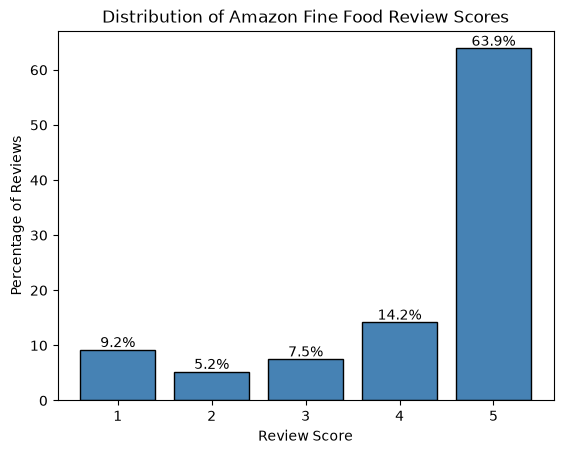

In [ ]:
scores = score_summary_polar["Score"].to_list()
percentages = score_summary_polar["Percentage"].to_list()

bars = plt.bar(
    scores,
    percentages,
    color="steelblue",
    edgecolor="black",
)

plt.title("Distribution of Amazon Fine Food Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Percentage of Reviews")
plt.xticks(scores)

for bar, percentage in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{percentage:.1f}%",
        ha="center",
    )

plt.savefig(
    "figures/review_score_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

**Finding:** The bar plot shows that the score distribution is highly imbalanced. Approximately 63.9% of all reviews have a score of 5, while only about 9.2% have a score of 1. Overall, positive ratings are considerably more common than neutral or negative ratings. This imbalance should be considered when building a machine learning model because a model could achieve high accuracy by favoring the majority positive class.

We can also use a boxplot to compare the distribution of helpfulness ratios across review scores. The analysis is limited to reviews with at least 10 helpfulness votes so that the ratios are based on a meaningful amount of reader feedback. A boxplot is appropriate here because it displays the median, variability, and potential outliers of a continuous variable across several rating categories.

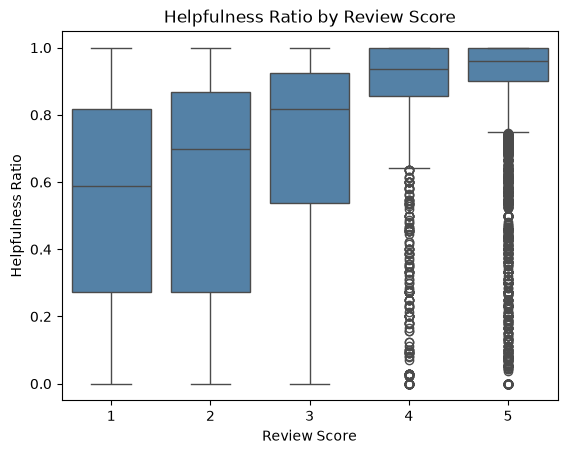

In [40]:
plot_data = reviews[
    (reviews["HelpfulnessDenominator"] >= 10)
    & (reviews["HelpfulnessRatio"].notna())
].copy()

sns.boxplot(
    data=plot_data,
    x="Score",
    y="HelpfulnessRatio",
    color="steelblue"
)

plt.title("Helpfulness Ratio by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Helpfulness Ratio")

plt.savefig(
    "figures/helpfulness_ratio_by_score.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

**Finding:** The median helpfulness ratio increases as the review score increases. One-star reviews have the lowest median helpfulness ratio, while five-star reviews have the highest median. The distributions for one and two-star reviews are also substantially wider, indicating greater variation in whether readers considered negative reviews helpful. Four- and five-star reviews generally have high helpfulness ratios, although both groups contain lower-ratio outliers. This result describes an association and does not establish that a higher score causes a review to be perceived as more helpful.

## 5. Machine Learning Exploration

The machine learning task is to predict whether a review is positive or negative based on its text. Reviews with scores of 1 or 2 are labeled as negative, while reviews with scores of 4 or 5 are labeled as positive. Reviews with a score of 3 are excluded because they are considered neutral. **TF-IDF** is used to convert review text into numerical features, and *logistic regression* is used as the binary classification algorithm.

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

### Preparing the Model Data

The original score is converted into a binary target variable named `Positive`. A value of 1 represents a positive review, and a value of 0 represents a negative review.

In [46]:
ml_data = reviews.loc[
    reviews["Score"] != 3,
    ["Text", "Score"],
].copy()

ml_data["Text"] = (
    ml_data["Text"]
    .str.replace(r"<br\s*/?>", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

ml_data["Positive"] = (
    ml_data["Score"] >= 4
).astype(int)

ml_data.head()

,Text,Score,Positive
0,I have bought several of the Vitality canned d...,5,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,0
2,This is a confection that has been around a fe...,4,1
3,If you are looking for the secret ingredient i...,2,0
4,Great taffy at a great price. There was a wide...,5,1


In [43]:
class_counts = ml_data["Positive"].value_counts().sort_index()

print("Negative reviews:", class_counts[0])
print("Positive reviews:", class_counts[1])

Negative reviews: 82037
Positive reviews: 443777


The full dataset contains much more positive reviews than negative reviews. To prevent the majority positive class from dominating this initial experiment, an equal number of positive and negative reviews is sampled for model training and evaluation.

In [44]:
negative_sample = ml_data[
    ml_data["Positive"] == 0
].sample(
    n = 20_000,
    random_state = 42,
)

positive_sample = ml_data[
    ml_data["Positive"] == 1
].sample(
    n = 20_000,
    random_state = 42,
)

ml_sample = pd.concat(
    [negative_sample, positive_sample],
    ignore_index = True,
).sample(
    frac = 1,
    random_state = 42,
).reset_index(drop = True)

print(f"Sample shape: {ml_sample.shape}")
print(ml_sample["Positive"].value_counts())

Sample shape: (40000, 3)
Positive
1    20000
0    20000
Name: count, dtype: int64


### Model Inputs and Target

The model input, `X`, contains the cleaned review text. The target variable, `y`, contains the known sentiment labels derived from the original review scores:

- `0`: negative review
- `1`: positive review

In [48]:
X = ml_sample["Text"]
y = ml_sample["Positive"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")

Training observations: 32000
Testing observations: 8000


### Converting Text into Numerical Features

Machine learning models cannot directly process raw text. Therefore, TF-IDF is used to convert each review into a collection of numerical features based on the words it contains.

The vectorizer is fitted using only the training data. The same fitted vectorizer is then used to transform the testing data.

In [50]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5_000,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (32000, 5000)
Testing data shape: (8000, 5000)


### Training the Logistic Regression Model

A logistic regression classifier is trained using the TF-IDF features. The model learns which words are associated with positive and negative reviews.

In [51]:
model = LogisticRegression(
    max_iter=1_000,
    random_state=42,
)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

### Making Predictions

The trained model is applied to the testing data to predict whether each review is positive or negative.

In [52]:
y_pred = model.predict(X_test_tfidf)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].to_numpy())

First 10 predictions:
[1 0 1 1 1 0 0 1 0 1]

First 10 actual labels:
[1 0 1 1 1 0 0 0 0 0]


### Calculate Model Accuracy

In [53]:
model_accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {model_accuracy:.3f}")

Model accuracy: 0.885


### Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
    )
)

### Confusion Matrix


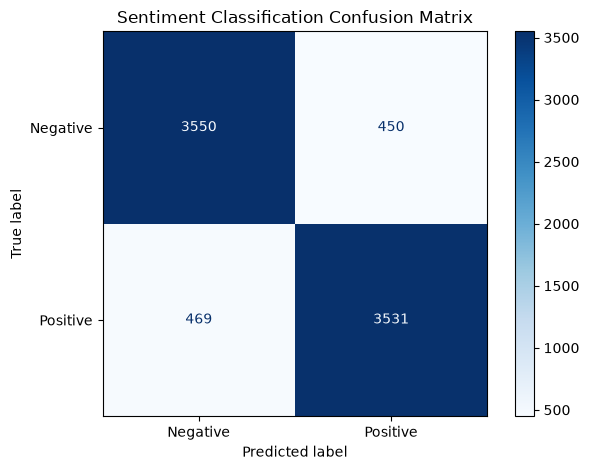

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues",
)

plt.title("Sentiment Classification Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "figures/sentiment_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Experimenting with Model Inputs and Outputs

The trained model is tested on several manually written review examples to observe its predicted outputs.

In [55]:
example_reviews = [
    "This product was delicious and I would definitely buy it again.",
    "The food tasted terrible and arrived completely damaged.",
    "The product is okay, but I expected better quality.",
]

example_predictions = sentiment_model.predict(example_reviews)
example_probabilities = sentiment_model.predict_proba(example_reviews)

for review, prediction, probabilities in zip(
    example_reviews,
    example_predictions,
    example_probabilities,
):
    predicted_label = (
        "Positive" if prediction == 1 else "Negative"
    )

    print(f"Review: {review}")
    print(f"Prediction: {predicted_label}")
    print(
        "Probability of positive review: "
        f"{probabilities[1]:.3f}"
    )
    print()

Review: This product was delicious and I would definitely buy it again.
Prediction: Positive
Probability of positive review: 0.971

Review: The food tasted terrible and arrived completely damaged.
Prediction: Negative
Probability of positive review: 0.012

Review: The product is okay, but I expected better quality.
Prediction: Negative
Probability of positive review: 0.052



### Machine Learning Findings

The original dataset contained 82,037 negative reviews and 443,777 positive reviews after neutral three-star reviews were excluded. Because the positive class was much larger, a balanced sample of 40,000 reviews was created using 20,000 randomly selected reviews from each class.

The logistic regression model achieved an accuracy of 0.885 on the balanced testing set of 8,000 reviews. The model performed similarly across both sentiment classes. For negative reviews, it achieved a precision of 0.88, recall of 0.89, and F1-score of 0.89. For positive reviews, it achieved a precision of 0.89, recall of 0.88, and F1-score of 0.88.

Because the two classes had equal representation in the testing data and similar precision and recall values, the model did not appear to strongly favor one sentiment class. Overall, this initial experiment suggests that TF-IDF features combined with logistic regression can identify meaningful sentiment patterns in Amazon food review text. However, the results are based on a balanced sample rather than the full original class distribution.